Cost cuối cùng: 5499.623355541983


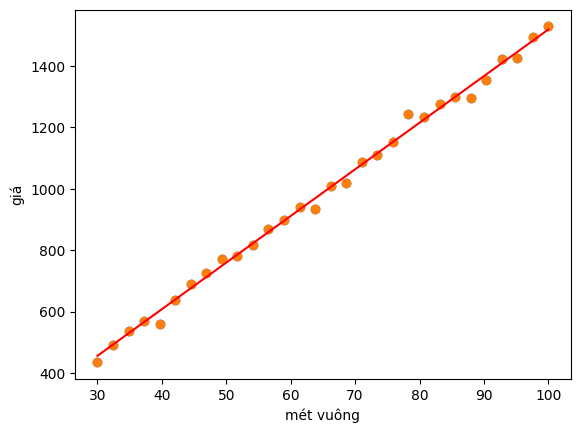

Giá nhà cho 50m^2 là: 759.7251557140971
w đọc từ file: [[ 0.18353643]
 [15.19083239]]


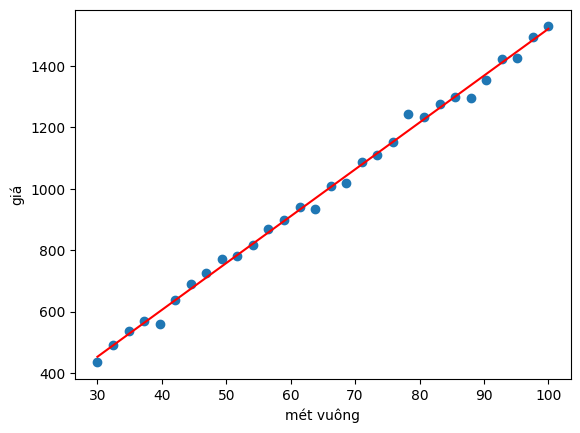

Intercept: [-4.91577939]
Coef: [[15.26193881]]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sinh dữ liệu
numOfPoint = 30
noise = np.random.normal(0, 1, numOfPoint).reshape(-1, 1)
x = np.linspace(30, 100, numOfPoint).reshape(-1, 1)
N = x.shape[0]
y = 15 * x + 8 + 20 * noise

plt.scatter(x, y)
plt.xlabel('mét vuông')
plt.ylabel('giá')

# Thêm cột bias
X = np.hstack((np.ones((N, 1)), x))

# Khởi tạo trọng số
w = np.array([0., 1.]).reshape(-1, 1)

numOfIteration = 1000
cost = np.zeros((numOfIteration, 1))
learning_rate = 0.000001

# Gradient Descent
for i in range(numOfIteration):
    r = np.dot(X, w) - y
    cost[i] = 0.5 * np.sum(r * r)

    w[0] -= learning_rate * np.sum(r)
    w[1] -= learning_rate * np.sum(r * X[:, 1].reshape(-1, 1))

print("Cost cuối cùng:", cost[-1][0])

# Dự đoán
predict = np.dot(X, w)

# Vẽ đường hồi quy
plt.scatter(x, y)
plt.plot((x[0][0], x[N-1][0]), (predict[0][0], predict[N-1][0]), 'r')
plt.xlabel('mét vuông')
plt.ylabel('giá')
plt.show()

# Dự đoán giá nhà 50m2
x1 = 50
y1 = w[0][0] + w[1][0] * x1
print('Giá nhà cho 50m^2 là:', y1)

# Lưu w với numpy.save(), định dạng '.npy'
np.save('weight.npy', w)

# Đọc lại file '.npy'
w = np.load('weight.npy')
print("w đọc từ file:", w)

# =========================
# LinearRegression với sklearn
# =========================


# 3.8 Bài tập 63
lrg = LinearRegression()

# Train mô hình
lrg.fit(x, y)

# Dự đoán
y_pred = lrg.predict(x)

plt.scatter(x, y)
plt.plot((x[0][0], x[-1][0]), (y_pred[0][0], y_pred[-1][0]), 'r')
plt.xlabel('mét vuông')
plt.ylabel('giá')
plt.show()

# Lưu nhiều tham số với numpy.savez()
np.savez('w2.npz', a=lrg.intercept_, b=lrg.coef_)

# Đọc lại các tham số
k = np.load('w2.npz')
lrg.intercept_ = k['a']
lrg.coef_ = k['b']

print("Intercept:", lrg.intercept_)
print("Coef:", lrg.coef_)

# Giải thích đoạn code hồi quy tuyến tính

## 1. Sinh dữ liệu
Đoạn đầu dùng `numpy` để tạo dữ liệu giả lập:

- `x`: diện tích nhà, nằm trong khoảng từ 30 đến 100 m².
- `noise`: nhiễu ngẫu nhiên để dữ liệu thực tế hơn.
- `y = 15*x + 8 + 20*noise`: giá nhà được tạo gần theo hàm bậc nhất.

Sau đó dùng `plt.scatter(x, y)` để vẽ biểu đồ phân tán giữa diện tích và giá.

---

## 2. Huấn luyện mô hình bằng Gradient Descent
Code thêm một cột toàn số 1 vào `x` để biểu diễn hệ số tự do:

- `w[0]`: bias
- `w[1]`: hệ số của diện tích

Thuật toán lặp nhiều lần để:

1. Tính sai số dự đoán `r = x.w - y`
2. Tính hàm mất mát `cost`
3. Cập nhật `w` để giảm sai số

> Lưu ý: phần cập nhật `w` phải nằm **bên trong vòng lặp** thì mô hình mới học đúng.

---

## 3. Dự đoán và vẽ đường thẳng hồi quy
Sau khi học xong, chương trình:

- Tính giá trị dự đoán `predict = np.dot(x, w)`
- Vẽ đường hồi quy tuyến tính lên biểu đồ
- Dự đoán giá nhà khi diện tích là `50 m²`

Công thức:
\[
y = w_0 + w_1 x
\]

---

## 4. Lưu và đọc lại trọng số
Code dùng:

- `np.save('weight.npy', w)` để lưu trọng số
- `np.load('weight.npy')` để đọc lại trọng số đã lưu

Việc này giúp không cần huấn luyện lại từ đầu.

---

## 5. Dùng thư viện `sklearn`
Phần sau sử dụng `LinearRegression` của `sklearn` để huấn luyện mô hình hồi quy tuyến tính từ file `data_linear.csv`.

Các bước gồm:

1. Đọc dữ liệu từ file CSV
2. Tạo mô hình `LinearRegression()`
3. Huấn luyện bằng `fit(x, y)`
4. Dự đoán bằng `predict(x)`
5. Vẽ đường hồi quy

---

## 6. Lưu tham số mô hình sklearn
Chương trình lưu các tham số của mô hình:

- `intercept_`: hệ số tự do
- `coef_`: hệ số góc

bằng `np.savez('w2.npz', ...)`, sau đó có thể đọc lại bằng `np.load()`.

---
